In [1]:
from limited_data_experiment import (
    score_oracle,
    do_experiment,
    load_experiments_data_spe,
    make_pandas,
)
import numpy as np
from itertools import count
import multiprocessing as mp
from functools import partial
from matplotlib import pyplot as plt

import seaborn as sns

font = 8
tex_fonts = {
    # "text.usetex": True,
    "font.family": "serif",
    "font.size": font,
    "axes.labelsize": font,
    "axes.titlesize": font,
    "xtick.labelsize": font,
    "ytick.labelsize": font,
    "legend.fontsize": font,
}

plt.rcdefaults()

sns.set_theme(
    # context="talk",
    context="paper",
    # rc={"figure.figsize": (8, 6)},
    # palette="colorblind6",
    style="whitegrid",
    rc=tex_fonts,
)

ALL_RUNS = [100, 101, 102, 103, 104]

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


# Random Experiment

In [2]:
sim_data_random, perf_data_random, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, case='random'
)
solver_space = solver_selector.solver_space
num_solvers = solver_space.all_decisions_encoding.shape[0]
print(num_solvers)
solver_space.num_category_choices, solver_space.num_numerical_choices

14415


(31, 16)

In [3]:
df_sim_rand, df_perf_rand = make_pandas(
    sim_data=sim_data_random,
    perf_data=perf_data_random,
    seq_ids=ALL_RUNS,
)

df_perf_rand.head()

,seq_id,sim_idx,reward,expectation,decision_idx,features
0,100,0,-200.000000,100.0,8666,"[864.0, 393.0, 393.0, 2.000608138170554e-14, 5..."
1,100,0,-0.602214,100.0,9274,"[864.0, 393.0, 393.0, 2.000608138170554e-14, 5..."
2,100,0,-200.000000,100.0,2558,"[864.0, 191.1878618948923, 393.00000233247454,..."
3,100,0,-1.023688,100.0,7849,"[864.0, 191.1878618948923, 393.00000233247454,..."
4,100,0,-0.511434,100.0,2047,"[864.0, 328.4624772543551, 393.00000062791497,..."


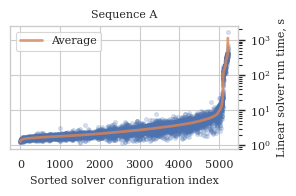

In [4]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf_rand.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
        # y_by_solver_id[row.decision_idx].append(1000)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

mean = []
std = []
for elem in y_by_solver_id:
    if len(elem) != 0:
        mean.append(np.mean(elem))
        std.append(np.std(elem))
    else:
        mean.append(np.nan)
        std.append(np.nan)

mean = np.array(mean)
std = np.array(std)

sorted_idx = np.argsort(mean)

idx = []
data = []
i = 0
for y in np.array(y_by_solver_id, dtype=object)[sorted_idx]:
    data.extend(y)
    idx.extend([i] * len(y))
    i += 1

plt.figure(figsize=(3,2))
plt.plot(mean[sorted_idx], color='C1', alpha=0.8, linewidth=2, label='Average')
plt.scatter(idx, data, marker='.', alpha=0.2, s=30)
# plt.ylim(1, 20)
# plt.yscale('log')
plt.grid(True)
plt.xlabel('Sorted solver configuration index')
plt.ylabel('Linear solver run time, s')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence A')
plt.yscale('log')
plt.tight_layout()

plt.savefig('figures/spe_sorted_run_times.png', dpi=600)

In [5]:
num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

5052 2845 167


In [6]:
import pandas as pd

success = df_perf_rand.reward > -200
ysuccess = np.exp(-df_perf_rand[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_rand.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success) / success.size * 100,
    '% num_always_success': num_always_success / num_solvers_tried * 100,
    '% num_always_failure': num_always_failure / num_solvers_tried * 100,
    '% num_swinging_success_failure': num_swinging / num_solvers_tried * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,14415.000000
num_points,19863.000000
% solvers_tried,55.941727
Success %,63.510044
% num_always_success,62.648810
% num_always_failure,35.280258
% num_swinging_success_failure,2.070933
Run time avg,8.516507
Run time median,2.448337
Run time min,1.143527


# Solver Selection Experiment

In [7]:
sim_data, perf_data, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, case='solver_selection'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim, df_perf = make_pandas(
    sim_data=sim_data,
    perf_data=perf_data,
    seq_ids=ALL_RUNS,
)
df_sim.head()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
0,100,0,0,0,16.919482,20,2,2.000608e-14,864.0,5.362207e-07,8.061838e-10,4.547474e-13,1.912830e-14
1,100,0,0,1,4.180653,10,2,5.919609e-01,864.0,1.607464e+07,3.494068e+03,3.087658e+02,4.825942e-03
2,100,0,0,2,2.539239,15,2,5.709300e-01,864.0,5.662066e+06,3.342763e+03,7.115681e+01,3.250292e-03
3,100,0,0,3,3.967273,7,2,5.710351e-01,864.0,6.808978e+06,3.352658e+03,6.219734e+01,3.142256e-03
4,100,0,0,4,3.143417,29,2,5.710357e-01,864.0,6.810293e+06,3.352670e+03,6.218720e+01,3.142097e-03


In [8]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

185 19 8


In [9]:
import pandas as pd

batch_size = 64
success = df_perf.reward > -200
ysuccess = np.exp(-df_perf[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    '% num_always_success': num_always_success / num_solvers_tried * 100,
    '% num_always_failure': num_always_failure / num_solvers_tried * 100,
    '% num_swinging_success_failure': num_swinging / num_solvers_tried * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,14415.000000
num_points,12887.000000
% solvers_tried,1.470690
Success %,98.136162
% num_always_success,87.264151
% num_always_failure,8.962264
% num_swinging_success_failure,3.773585
Run time avg,1.654127
Run time median,1.589907
Run time min,0.480082


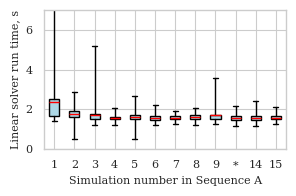

In [10]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

num_sims = 15
num_left = 9
num_right = 2
assert num_sims >= (num_left + num_right)
sims = [[x] for x in range(num_left)] + [range(num_left, num_sims - num_right)] + [[x] for x in range(num_sims - num_right, num_sims)]

# sims = [[x] for x in range(15)]# + [[6,7]] + [[8]] + [[x] for x in range(8, 12)] + [[13]] + [[14]]
# sims = [[x] for x in range(15)]# + [[6,7]] + [[8]] + [[x] for x in range(8, 12)] + [[13]] + [[14]]


perf_data_per_sim = []

for sim_id in sims:
    tmp = df_perf[(df_perf.sim_idx.isin(sim_id))]
    y = np.exp(-tmp.reward[tmp.reward > -200])
    perf_data_per_sim.append(np.array(y))

plt.figure(figsize=(3, 2))
plt.boxplot(
    perf_data_per_sim,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color='black', linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle='-', linewidth=1, color='red'),  # mean as red line
    flierprops=dict(marker='', linestyle='none'),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)
# plt.xticks(range(1, 16), range(15))
plt.xticks(range(1, num_left + 1 + num_right + 1), labels=[str(x+1) for x in range(num_left)] + ['*'] + [str(x+1) for x in range(num_sims - num_right, num_sims)])

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Interquartile Range (Q1–Q3)')

# plt.legend(handles=[mean_line, iqr_box], loc='upper right')
plt.xlabel("Simulation number in Sequence A")
plt.ylabel("Linear solver run time, s")
plt.ylim(0, 7)
plt.tight_layout()
plt.savefig('figures/spe_boxplot_sim_number.png', dpi=600)

In [11]:
perf_data_per_sim[0].max()

53.916667938232415

9

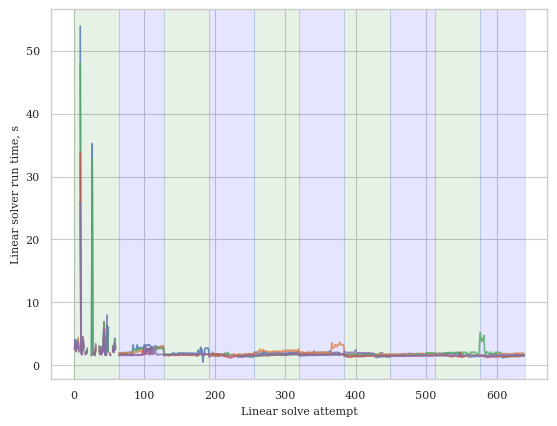

In [12]:
batch_size = 64
max_points = batch_size * 10
num_batches = max_points // batch_size

data_len = 0
for seq_id in ALL_RUNS:
    tmp = df_perf[df_perf.seq_id == seq_id]
    failure = np.array(tmp.reward <= -200)
    y = np.exp(-np.array(tmp.reward))
    y[failure] = np.nan
    y = y[:max_points]
    plt.plot(y, alpha=0.8)
    data_len = max(data_len, y.size)


colors = ["green", "blue"]

for b in range(num_batches):
    if (batch_size * (b + 1)) > data_len:
        break 
    plt.axvspan(batch_size * b, batch_size * (b + 1), alpha=0.1, color=colors[b % 2])

plt.ylabel("Linear solver run time, s")
plt.xlabel("Linear solve attempt")
b

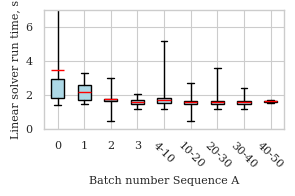

In [13]:
batches = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 10],
    [10, 20],
    [20, 30],
    [30, 40],
    [40, 50],
]
perf_data_per_batch = []

for bstart, bend in batches:
    tmp_list = []
    perf_data_per_batch.append(tmp_list)
    for seq_id in ALL_RUNS:
        tmp = df_perf[df_perf.seq_id == seq_id][bstart * batch_size : bend * batch_size]
        y = np.exp(-tmp.reward[tmp.reward > -200])
        tmp_list.extend(y.tolist())


plt.figure(figsize=(3, 2))
_ = plt.boxplot(
    perf_data_per_batch,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)

plt.xticks(
    range(1, len(batches) + 1),
    labels=[
        start if (end - start) == 1 else f"{start}-{end}" for start, end in batches
    ],
)
for i, tick in enumerate(plt.gca().get_xticklabels()):
    if i >= 4:  # rotate ticks 4-8
        tick.set_rotation(-45)
    else:         # leave 0-3 unrotated
        tick.set_rotation(0)

# mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
# iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Interquartile Range (Q1–Q3)')

# plt.legend(handles=[iqr_box, mean_line], loc='upper center', bbox_to_anchor=(1, 1))

plt.ylim(0, 7)
plt.xlabel("Batch number Sequence A")
plt.ylabel("Linear solver run time, s")
plt.tight_layout()
plt.savefig('figures/spe_boxplot_batches.png', dpi=600)

In [14]:
num_data_points_in_sim = []
for sim_id in range(15):
    tmp = df_perf[(df_perf.seq_id == ALL_RUNS[0]) & (df_perf.sim_idx == sim_id)]
    num_data_points_in_sim.append(tmp.shape[0])
num_data_points_in_sim

[174, 204, 172, 158, 168, 187, 158, 158, 158, 158, 180, 174, 158, 175, 158]

In [15]:
174 / 64

2.71875

In [16]:
(174 + 204) / 64

5.90625

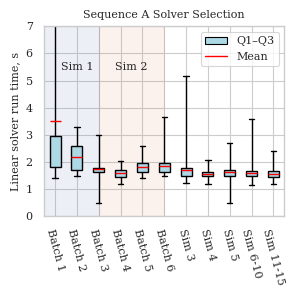

In [17]:
batches = range(6)
perf_data_per_batch = []

for bstart in batches:
    bend = bstart + 1
    tmp_list = []
    perf_data_per_batch.append(tmp_list)
    for seq_id in ALL_RUNS:
        tmp = df_perf[df_perf.seq_id == seq_id][bstart * batch_size : bend * batch_size]
        y = np.exp(-tmp.reward[tmp.reward > -200])
        tmp_list.extend(y.tolist())

sims = [[2], [3], [4], list(range(5,10)), list(range(10,15))]

for sim_id in sims:
    tmp = df_perf[df_perf.sim_idx.isin(sim_id)]
    y = np.exp(-tmp.reward[tmp.reward > -200])
    perf_data_per_batch.append(np.array(y))


plt.figure(figsize=(3, 3))
_ = plt.boxplot(
    perf_data_per_batch,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)

# plt.xticks(
#     range(1, len(batches) + 1),
#     labels=[
#         start + 1 if (end - start) == 1 else f"{start + 1}-{end + 1}"
#         for start, end in batches
#     ],
# )
# for i, tick in enumerate(plt.gca().get_xticklabels()):
#     if i >= 4:  # rotate ticks 4-8
#         tick.set_rotation(-45)
#     else:  # leave 0-3 unrotated
#         tick.set_rotation(0)

plt.axvspan(0, 3, alpha=0.1, color='C0')
plt.axvspan(3, 6, alpha=0.1, color='C1')
plt.xticks(
    range(1, len(perf_data_per_batch) + 1),
    [f'Batch {i+1}' for i in batches] + [f'Sim {x[0]+1}' if len(x)==1 else f'Sim {min(x)+1}-{max(x)+1}' for x in sims],
    rotation=-75
)
plt.text(2, 5.4, 'Sim 1', ha='center')
plt.text(4.5, 5.4, 'Sim 2', ha='center')

plt.xlim(left=0.5)

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
plt.legend(handles=[iqr_box, mean_line], loc='upper right')


# plt.xlabel("Batch number Sequence B")
plt.title('Sequence A Solver Selection')

plt.ylim(top=7, bottom=0)
plt.ylabel(r"Linear solver run time, s")
plt.tight_layout()
plt.savefig("figures/spe_boxplot_batches_and_simulations.png", dpi=600)

/tmp/ipykernel_2167101/2724636545.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


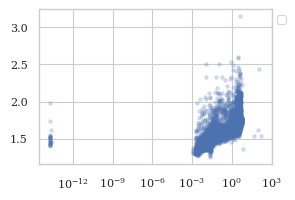

In [18]:
plt.figure(figsize=(3,2))

tmp = df_sim[df_sim.sim_idx.isin(range(10, 15))]
x = np.array(tmp.fourier_mean)
y = np.array(tmp.real_solve_time)

filter = (y < 30) & (y > 0.0002)  # drop failures and anomalies
x = x[filter]
y = y[filter]

plt.scatter(x, y, alpha=0.2, marker='.')
# plt.ylim(3.5, 9.5)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.xscale('log')

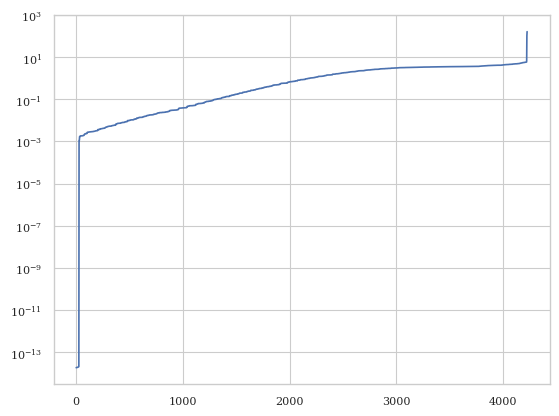

In [19]:
plt.plot(np.sort(x))
plt.yscale('log')

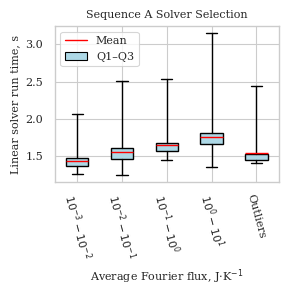

In [20]:
bins = 10.0 ** np.arange(-3, 2)
perf_data_per_dt = []
xticklabels = []
for bin_start, bin_end in zip(bins[:-1], bins[1:]):
    perf_data_per_dt.append(y[(x >= bin_start) & (x < bin_end)])
    pow = int(np.log10(bin_start))
    xticklabels.append("$10^{" + str(pow) + "} - 10^{" + str(pow + 1) + "}$")

# outliers
perf_data_per_dt.append(y[(x < bins[0]) | (x >= bins[-1])])
xticklabels.append("Outliers")

plt.figure(figsize=(3, 3))
plt.boxplot(
    perf_data_per_dt,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)
plt.xticks(np.arange(1, len(bins) + 1), xticklabels, rotation=-75)
plt.title("Sequence A Solver Selection")

# plt.ylim(top=7, bottom=0)
plt.xlabel('Average Fourier flux, J$\cdot$K$^{-1}$')
plt.ylabel(r"Linear solver run time, s")

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
plt.legend(handles=[mean_line, iqr_box], loc='upper left')
# plt.ylim(top=4)

plt.tight_layout()
plt.savefig("figures/spe_boxplot_fourier.png", dpi=600)

In [21]:
tmp = [len(x) for x in perf_data_per_dt]
print(tmp)
tmp[-1] / sum(tmp) * 100

[480, 813, 873, 2032, 30]


0.7095553453169348

In [22]:
perf_data_per_dt[-1].min()

1.4082493782043457

6 622


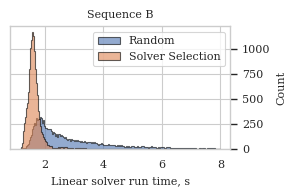

In [23]:
data = np.exp(-df_perf.reward[df_perf.reward > -200])
data_rand = np.exp(-df_perf_rand.reward[df_perf_rand.reward > -200])

bins = 200
upper_lim = 8
bins = np.linspace(min(data_rand), upper_lim, bins)
plt.figure(figsize=(3,2))
plt.hist(data_rand, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Random', histtype='stepfilled')
plt.hist(data, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Solver Selection', histtype='stepfilled')

plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
# plt.yscale('log')
plt.legend()
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.title('Sequence B')
plt.tight_layout()
plt.savefig('figures/spe_runtime_histogram.png', dpi=600)

print(np.sum(data > upper_lim), np.sum(data_rand > upper_lim))

In [24]:
# from limited_data_experiment import (
#     EpsGreedyExplorationModel,
#     GradientBoostingRegressor,
#     IncrementalRefitModel,
#     RidgeClassifier,
#     StandardScaler,
#     TwoEstimators,
#     make_pipeline,
#     stack_features_solvers,
# )
# from time import time
# from tqdm import tqdm
# from solver_selection_thm.performance_predictor import InitialExplorationEstimator


# def ml_overhead(df_perf: pd.DataFrame):
#     df_perf = df_perf[df_perf.seq_id == ALL_RUNS[0]]
#     X = np.stack(df_perf.features)
#     X = np.clip(X, -1e10, 1e10)

#     online_model = InitialExplorationEstimator(
#         num_initial_exploration=64,
#         batch_size=64,
#         model=EpsGreedyExplorationModel(
#             eps=0,
#             eps1=0.9,
#             model=TwoEstimators(
#                 classifier=IncrementalRefitModel(
#                     model=make_pipeline(StandardScaler(), RidgeClassifier())
#                 ),
#                 regressor=IncrementalRefitModel(
#                     model=GradientBoostingRegressor(random_state=42)
#                 ),
#             ),
#         ),
#     )
#     tpred = []
#     tfit = []

#     all_solvers = solver_selector.solver_space.all_decisions_encoding
#     # only solution context (no solvers encoding)
#     X_context = X[:, : -all_solvers.shape[1]]

#     for Xfeature in tqdm(X_context):
#         t0 = time()
#         x_to_predict = stack_features_solvers(Xfeature, all_solvers)
#         online_model.select_solver(x_to_predict)
#         tpred.append(time() - t0)
#         t0 = time()
#         online_model.partial_fit(
#             features=x_to_predict[np.random.randint(all_solvers.shape[0])],
#             solve_time=np.random.rand(),
#             construct_time=np.random.rand(),
#             success=True,
#         )
#         tfit.append(time() - t0)
#     return np.array(tpred), np.array(tfit)


# tpred, tfit = ml_overhead(df_perf)

In [25]:
# plt.figure(figsize=(3,2))
# plt.plot(np.cumsum(tpred), label='Selection')
# plt.plot(np.cumsum(tfit), label='Feedback')
# plt.legend()
# plt.ylabel('Cumulative\noverhead, s')
# plt.xlabel('Num. linear systems seen')
# plt.title('Sequence A')
# plt.tight_layout()
# plt.savefig('figures/spe_ml_overhead.png', dpi=600)

In [26]:
np.mean(tpred[64:]), np.std(tpred[64:])

NameError: name 'tpred' is not defined

# Expert Experimnet

In [ ]:
sim_data_expert, perf_data_expert, solver_selector = load_experiments_data_spe(
    runs=ALL_RUNS, case='expert'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim_expert, df_perf_expert = make_pandas(
    sim_data=sim_data_expert,
    perf_data=perf_data_expert,
    seq_ids=ALL_RUNS,
)
df_sim_expert.tail()

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
12620,104,14,50,1,1.667457,19,2,47196.602678,8.640000e+07,2.625054e+06,1083.400745,307.285717,4.104633
12621,104,14,50,2,1.632930,18,2,47196.602678,8.640000e+07,2.625054e+06,1083.400921,307.285716,4.104632
12622,104,14,51,0,1.673980,19,2,26495.559534,4.850384e+07,2.625054e+06,1083.400921,307.285716,4.104632
12623,104,14,51,1,1.612550,18,2,26495.559558,4.850384e+07,2.625054e+06,1082.979562,307.286353,4.103629
12624,104,14,51,2,1.611387,18,2,26495.559558,4.850384e+07,2.625054e+06,1082.979603,307.286353,4.103629


In [ ]:
import pandas as pd

success = df_perf_expert.reward > -200
ysuccess = np.exp(-df_perf_expert[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_expert.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,14415.000000
num_points,12620.000000
% solvers_tried,1.470690
Success %,100.000000
Run time avg,1.561314
Run time median,1.556277
Run time min,0.453285
Run time max,2.255378


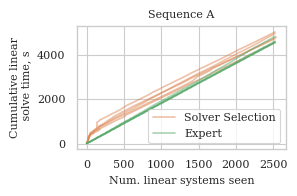

In [ ]:
plt.figure(figsize=(3,2))

first_time = True
for seq_id in ALL_RUNS:
    # y = np.array(df_perf.reward[(df_perf.reward > -200) & (df_perf.seq_id == seq_id)])
    # y = np.exp(-y)
    y = np.array(df_sim.real_solve_time[df_sim.seq_id == seq_id])
    y = np.cumsum(y)
    kwargs = {}
    if first_time:
        first_time = False
        kwargs = dict(label='Solver Selection')
    plt.plot(y, color="C1", **kwargs, alpha=0.5)

first_time = True
for seq_id in ALL_RUNS:
    # y = np.array(df_perf_expert.reward[(df_perf_expert.reward > -200) & (df_perf_expert.seq_id == seq_id)])
    # y = np.exp(-y)
    y = np.array(df_sim_expert.real_solve_time[df_sim_expert.seq_id == seq_id])
    y = np.cumsum(y)
    kwargs = {}
    if first_time:
        first_time = False
        kwargs = dict(label='Expert')
    plt.plot(y, color="C2", **kwargs, alpha=0.5)

# plt.plot(np.cumsum(tpred), label='Selection')
# plt.plot(np.cumsum(tfit), label='Feedback')
# plt.yscale('log')

plt.ylabel('Cumulative linear\n solve time, s')
plt.xlabel('Num. linear systems seen')
plt.legend()
plt.title('Sequence A')

plt.tight_layout()
plt.savefig('figures/spe_runtime_expert.png', dpi=600)

# Analyzing Individual Decisions

In [ ]:
import pandas as pd
from solver_selection_thm.solver_space import explain_decisions

solver_space = solver_selector.solver_space
decision_names, decision_ranges = explain_decisions(solver_space)


perf_dict_for_pandas = []
for row in df_perf.itertuples(index=False):
    decision_vec = solver_space.all_decisions_encoding[row.decision_idx]
    perf_dict_for_pandas.append(
        {name: val for name, val in zip(decision_names, decision_vec)}
    )

column_dtypes = {x: bool for x in decision_names[:solver_space.num_category_choices]} 
column_dtypes |= {x: float for x in decision_names[solver_space.num_category_choices:]} 
tmp = pd.DataFrame(perf_dict_for_pandas).astype(column_dtypes)

df_perf_detailed = pd.concat([df_perf, tmp], axis=1)
df_perf_detailed['time'] = np.exp(-df_perf_detailed.reward)
df_perf_detailed = df_perf_detailed.drop('features', axis=1)
df_perf_detailed

,seq_id,sim_idx,reward,expectation,decision_idx,PetscFieldSplitScheme - ilu,PetscFieldSplitScheme,PetscFieldSplitScheme - sor,PetscFieldSplitScheme - pbjacobi,PetscFieldSplitScheme - hypre - symmetric-SOR/Jacobi,...,PetscKSPScheme - PetscFieldSplitScheme - gamg - python_pc_gamg_aggressive_coarsening,PetscKSPScheme - PetscFieldSplitScheme - gamg - python_mg_levels_ksp_max_it,PetscKSPScheme - PetscCompositeScheme - hypre - pc_hypre_boomeramg_strong_threshold,PetscKSPScheme - PetscCompositeScheme - hypre - pc_hypre_boomeramg_agg_nl,PetscKSPScheme - PetscCompositeScheme - hypre - pc_hypre_boomeramg_grid_sweeps_all,PetscKSPScheme - PetscCompositeScheme - gamg - pc_gamg_threshold,PetscKSPScheme - PetscCompositeScheme - gamg - pc_gamg_agg_nsmooths,PetscKSPScheme - PetscCompositeScheme - gamg - pc_gamg_aggressive_coarsening,PetscKSPScheme - PetscCompositeScheme - gamg - mg_levels_ksp_max_it,time
0,100,0,-200.000000,100.000000,7270,False,False,False,False,False,...,0.0,0.0,0.6,0.0,2.0,0.0,0.0,0.0,0.0,7.225974e+86
1,100,0,-1.176043,100.000000,860,False,True,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.241521e+00
2,100,0,-1.411122,100.000000,5390,False,False,False,False,False,...,0.0,0.0,0.7,0.0,3.0,0.0,0.0,0.0,0.0,4.100552e+00
3,100,0,-0.899873,100.000000,13418,False,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,3.0,2.459290e+00
4,100,0,-1.357444,100.000000,5191,False,False,False,False,False,...,0.0,0.0,0.5,0.0,2.0,0.0,0.0,0.0,0.0,3.886247e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12882,104,14,-0.486609,-0.479174,6777,False,False,False,False,False,...,0.0,0.0,0.6,1.0,1.0,0.0,0.0,0.0,0.0,1.626791e+00
12883,104,14,-0.462609,-0.479174,6777,False,False,False,False,False,...,0.0,0.0,0.6,1.0,1.0,0.0,0.0,0.0,0.0,1.588212e+00
12884,104,14,-0.461882,-0.479174,6777,False,False,False,False,False,...,0.0,0.0,0.6,1.0,1.0,0.0,0.0,0.0,0.0,1.587059e+00
12885,104,14,-0.460085,-0.479174,6777,False,False,False,False,False,...,0.0,0.0,0.6,1.0,1.0,0.0,0.0,0.0,0.0,1.584209e+00


In [ ]:
sorted(list(df_perf_detailed.columns))

['PetscCompositeScheme',
 'PetscCompositeScheme - gamg',
 'PetscCompositeScheme - gamg - V',
 'PetscCompositeScheme - gamg - W',
 'PetscCompositeScheme - hypre',
 'PetscCompositeScheme - hypre - Jacobi',
 'PetscCompositeScheme - hypre - SOR/Jacobi',
 'PetscCompositeScheme - hypre - V',
 'PetscCompositeScheme - hypre - W',
 'PetscCompositeScheme - hypre - l1scaled-Jacobi',
 'PetscCompositeScheme - hypre - symmetric-SOR/Jacobi',
 'PetscCompositeScheme - ilu',
 'PetscCompositeScheme - jacobi',
 'PetscCompositeScheme - none',
 'PetscCompositeScheme - pbjacobi',
 'PetscCompositeScheme - sor',
 'PetscFieldSplitScheme',
 'PetscFieldSplitScheme - gamg',
 'PetscFieldSplitScheme - gamg - V',
 'PetscFieldSplitScheme - gamg - W',
 'PetscFieldSplitScheme - hypre',
 'PetscFieldSplitScheme - hypre - Jacobi',
 'PetscFieldSplitScheme - hypre - SOR/Jacobi',
 'PetscFieldSplitScheme - hypre - V',
 'PetscFieldSplitScheme - hypre - W',
 'PetscFieldSplitScheme - hypre - l1scaled-Jacobi',
 'PetscFieldSplitSch

In [ ]:
def make_hist(df: pd.DataFrame, label: str):
    bins = 30
    bins = np.linspace(1, 4, bins, endpoint=True)
    y = df.reward[df.reward > -200]
    y = np.exp(-y)
    plt.hist(y, label=f'{label}, {y.size} points', alpha=0.6, bins=bins, density=True, edgecolor="black", histtype='stepfilled')

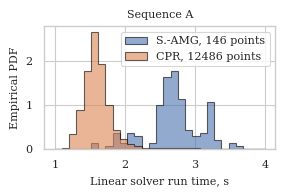

In [ ]:
plt.figure(figsize=(3,2))
make_hist(df_perf_detailed[df_perf_detailed['PetscFieldSplitScheme'] == True], label='S.-AMG')
make_hist(df_perf_detailed[df_perf_detailed['PetscCompositeScheme'] == True], label='CPR')
plt.ylabel('Empirical PDF')
plt.xlabel('Linear solver run time, s')
plt.title('Sequence A')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/spe_system_amg_vs_cpr.png', dpi=600)

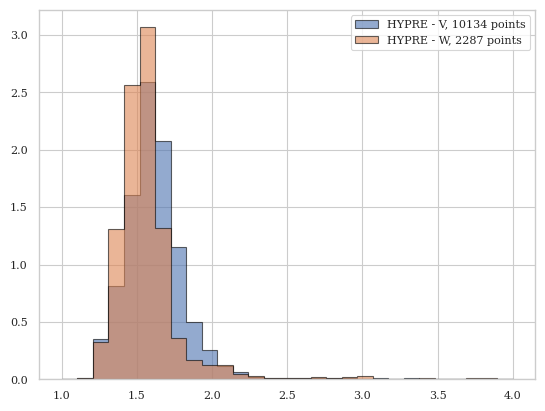

In [ ]:
make_hist(df_perf_detailed[df_perf_detailed['PetscCompositeScheme - hypre - V'] == True], label='HYPRE - V')
make_hist(df_perf_detailed[df_perf_detailed['PetscCompositeScheme - hypre - W'] == True], label='HYPRE - W')
plt.legend()

# How many bad solvers?

In [ ]:
import pandas as pd
from solver_selection_thm.solver_space import explain_decisions

solver_space = solver_selector.solver_space
decision_names, decision_ranges = explain_decisions(solver_space)
decision_names

['PetscFieldSplitScheme - ilu',
 'PetscFieldSplitScheme',
 'PetscFieldSplitScheme - sor',
 'PetscFieldSplitScheme - pbjacobi',
 'PetscFieldSplitScheme - hypre - symmetric-SOR/Jacobi',
 'PetscFieldSplitScheme - hypre - V',
 'PetscFieldSplitScheme - hypre',
 'PetscFieldSplitScheme - hypre - W',
 'PetscFieldSplitScheme - hypre - l1scaled-Jacobi',
 'PetscFieldSplitScheme - hypre - SOR/Jacobi',
 'PetscFieldSplitScheme - hypre - Jacobi',
 'PetscFieldSplitScheme - gamg - V',
 'PetscFieldSplitScheme - gamg',
 'PetscFieldSplitScheme - gamg - W',
 'PetscCompositeScheme - hypre - symmetric-SOR/Jacobi',
 'PetscCompositeScheme - hypre - V',
 'PetscCompositeScheme - hypre',
 'PetscCompositeScheme - sor',
 'PetscCompositeScheme - ilu',
 'PetscCompositeScheme',
 'PetscCompositeScheme - sor',
 'PetscCompositeScheme - pbjacobi',
 'PetscCompositeScheme - jacobi',
 'PetscCompositeScheme - none',
 'PetscCompositeScheme - hypre - W',
 'PetscCompositeScheme - hypre - l1scaled-Jacobi',
 'PetscCompositeScheme 

In [ ]:
num_with_ilu = (solver_space.all_decisions_encoding[:, 0] == True).sum()
num_with_sor = (solver_space.all_decisions_encoding[:, 2] == True).sum()
num_with_pbjacobi = (solver_space.all_decisions_encoding[:, 3] == True).sum()
total = solver_space.all_decisions_encoding.shape[0]
print(f'{num_with_ilu = }, {num_with_sor = }, {num_with_pbjacobi = }, {total = }')
print(num_with_ilu + num_with_sor + num_with_pbjacobi)
print((num_with_ilu + num_with_sor + num_with_pbjacobi) / total * 100, '%')

num_with_ilu = 9, num_with_sor = 3, num_with_pbjacobi = 3, total = 14415
15
0.10405827263267431 %
